# Data preparation

This notebook contains code to prepare the [PXD014777 dataset](https://proteomecentral.proteomexchange.org/cgi/GetDataset?ID=PXD014777) - Tenzer.nomatching_MaxQuant.txt.zip and HeLa10replicates2h-1.0.10.4_MaxQuant.txt.zip. 

We'll use the following txt files from the zip-files:

HeLa10replicates2h-1.0.10.4_MaxQuant.txt.zip:
- allPeptides.txt: All the peptides with MS-1 data for HeLa
- evidence.txt: A subset of the peptides in allPeptides.txt, which contains both MS-1 and MS-2 data


Tenzer.nomatching_MaxQuant.txt.zip:
- evidence.txt: Contains both MS-1 and MS-2 data for the 3 species: Ecoli, Yeast and HeLa

In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import os
import pandas as pd

import pipp
import pipp.utils

import re
import numpy as np
import matplotlib.pyplot as plt

Let's define the paths to the raw data.

In [2]:
HELA_MS_PATH    = "../../data/PXD014777/raw/hela/allPeptides.txt"
HELA_MSMS_PATH    = "../../data/PXD014777/raw/hela/evidence.txt"
SPECIES_MSMS_PATH = "../../data/PXD014777/raw/species/evidence.txt"

Let's define the paths to the processed output data.

In [3]:
HELA_MSMS_MAPPED_PATH = "../../data/PXD014777/processed/hela_mapped_ms2.csv"

HELA_MS_OUT_PATH    = "../../data/PXD014777/processed/hela_ms1.csv"
HELA_MSMS_OUT_PATH    = "../../data/PXD014777/processed/hela_ms2.csv"
SPECIES_MSMS_OUT_PATH = "../../data/PXD014777/processed/species_ms2.csv"

Let's process the data.

In [4]:
df_ms_hela_raw = pd.read_csv(HELA_MS_PATH, sep="\t", header=0)

In [5]:
df_ms_hela_raw["dataset"] = "HeLa"
df_ms_hela_raw["id"] = np.arange(0, len(df_ms_hela_raw))

As mentioned in the introduction, the MS/MS data is a subset of the MS data (with additional features). However, it is not trivial to map the MS/MS data back to the MS data, due to small differences in feature values. Hence, we can't just compare the features: ['Raw file', 'Charge', 'm/z', 'Mass', 'Intensity', 'Retention time'].
Instead we'll compute a mapping here as we'll later need to know which entries in the MS data corresponds to the MS/MS data. The indices in MS/MS data will match those in MS data - after performing the "mapping".

In [6]:
if not os.path.isfile(HELA_MSMS_MAPPED_PATH):
    df_msms_hela_raw = pd.read_csv(HELA_MSMS_PATH, sep="\t", header=0, low_memory=False)
    df_msms_hela_raw = pipp.utils.link_MSMS_to_MS(
        df_msms_hela_raw, df_ms_hela_raw, verbose=True
    )
    os.makedirs(os.path.dirname(HELA_MSMS_MAPPED_PATH), exist_ok=True)
    df_msms_hela_raw.to_csv(HELA_MSMS_MAPPED_PATH, sep="\t", index=False)

In [7]:
df_msms_hela_raw = pd.read_csv(
    HELA_MSMS_MAPPED_PATH, sep="\t", header=0, low_memory=False
)
df_msms_hela_raw["dataset"] = "HeLa"

In [8]:
df_msms_species_raw = pd.read_csv(
    SPECIES_MSMS_PATH, sep="\t", header=0, low_memory=False
)
df_msms_species_raw["dataset"] = "multi-species"

Let's look at the dimensions of the data.

In [9]:
print("HeLa MS data shape:        {}".format(df_ms_hela_raw.shape))
print("HeLa MS + MS/MS data shape:    {}".format(df_msms_hela_raw.shape))
print("species MS + MS/MS data shape: {}".format(df_msms_species_raw.shape))

HeLa MS data shape:        (4101555, 26)
HeLa MS + MS/MS data shape:    (634466, 71)
species MS + MS/MS data shape: (219367, 71)


### MS data preprocessing

Let's look at the features available in the MS data:

In [10]:
df_ms_hela_raw.columns.unique()

Index(['Raw file', 'Charge', 'm/z', 'Mass', 'Resolution',
       'Number of data points', 'Number of frames', 'Number of isotopic peaks',
       'Isotope correlation', 'Mass fractional part', 'Mass deficit',
       'Retention time', 'Retention length', 'Retention length (FWHM)',
       'Min frame index', 'Max frame index', 'Ion mobility index',
       'Ion mobility index length', 'Ion mobility index length (FWHM)',
       'Intensity', 'Intensities', 'Number of pasef MS/MS', 'Pasef MS/MS IDs',
       'MS/MS scan number', 'dataset', 'id'],
      dtype='object')

Let's filter out low quality peptides.

In [11]:
df_ms_hela = df_ms_hela_raw.loc[
    (df_ms_hela_raw["Charge"] != 1) & (df_ms_hela_raw["Intensity"] > 0)
]

In [12]:
ms_hela_raw_peptides_per_run = [
    np.sum(df_ms_hela_raw["Raw file"] == run)
    for run in df_ms_hela_raw["Raw file"].unique()
]
ms_hela_peptides_per_run = [
    np.sum(df_ms_hela["Raw file"] == run)
    for run in df_ms_hela["Raw file"].unique()
]

Text(0, 0.5, 'Number of peptides')

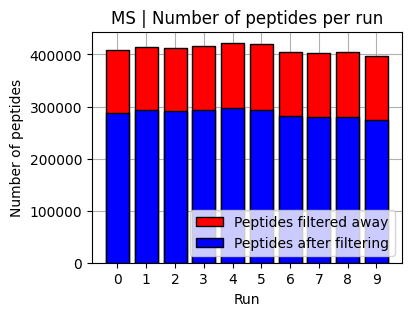

In [13]:
fig, ax = plt.subplots(figsize=(4, 3))

ax.bar(
    range(len(ms_hela_raw_peptides_per_run)),
    ms_hela_raw_peptides_per_run,
    color="red",
    edgecolor="black",
)
ax.bar(
    range(len(ms_hela_peptides_per_run)),
    ms_hela_peptides_per_run,
    color="blue",
    edgecolor="black",
)
ax.legend(["Peptides filtered away", "Peptides after filtering"], loc="lower right")

ax.grid(True)
ax.set_axisbelow(True)
ax.set_xticks(np.arange(0, len(ms_hela_raw_peptides_per_run), 1))
ax.set_title("MS | Number of peptides per run")
ax.set_xlabel("Run")
ax.set_ylabel("Number of peptides")

In [14]:
f"After filtering | MS data points: {df_ms_hela.shape[0]} ({df_ms_hela.shape[0] / df_ms_hela_raw.shape[0] * 100:.2f}%)"

'After filtering | MS data points: 2871496 (70.01%)'

It seems like the two types of datasets (MS and MS/MS) use a different name for 'Ion mobilility index length' / 'Ion mobility length'. Let's rename one of them to be consistent between the datasets.

In [15]:
df_ms_hela = df_ms_hela.copy()
df_ms_hela.rename(
    columns={"Ion mobility index length": "Ion mobility length"}, inplace=True
)

### MS/MS data preprocessing

#### HeLa - MS/MS data

Let's filter out low quality peptides.

In [16]:
# filter out low quality peptides
df_msms_hela = df_msms_hela_raw.loc[
    (df_msms_hela_raw["Charge"] != 1) & (df_msms_hela_raw["Intensity"] > 0)
]

# keep the most intense peptides
df_msms_hela = df_msms_hela.loc[
    df_msms_hela.groupby(["Modified sequence", "Charge", "Raw file"])[
        "Intensity"
    ].idxmax()
]

# remove contaminants
df_msms_hela = df_msms_hela.loc[
    [
        (not bool(re.search("CON__|REV__", i)))
        for i in df_msms_hela["Leading razor protein"].tolist()
    ]
]

# define identifier for each peptide
df_msms_hela["PrecursorID"] = (
    df_msms_hela["Modified sequence"]
    .astype(str)
    .str.cat(df_msms_hela["Charge"].astype(str), sep="")
)

In [17]:
msms_hela_raw_peptides_per_run = [
    np.sum(df_msms_hela_raw["Raw file"] == run)
    for run in df_msms_hela_raw["Raw file"].unique()
]
msms_hela_peptides_per_run = [
    np.sum(df_msms_hela["Raw file"] == run)
    for run in df_msms_hela["Raw file"].unique()
]

Text(0, 0.5, 'Number of peptides')

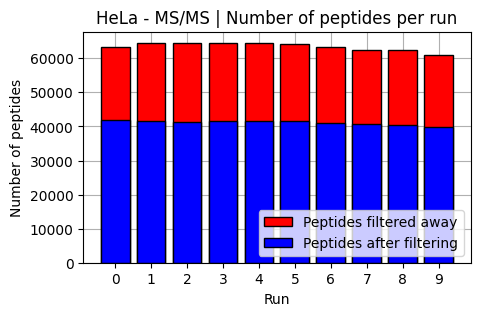

In [18]:
fig, ax = plt.subplots(figsize=(5, 3))

ax.bar(
    range(len(msms_hela_raw_peptides_per_run)),
    msms_hela_raw_peptides_per_run,
    color="red",
    edgecolor="black",
)
ax.bar(
    range(len(msms_hela_peptides_per_run)),
    msms_hela_peptides_per_run,
    color="blue",
    edgecolor="black",
)
ax.legend(["Peptides filtered away", "Peptides after filtering"], loc="lower right")

ax.grid(True)
ax.set_axisbelow(True)
ax.set_title("HeLa - MS/MS | Number of peptides per run")
ax.set_xticks(np.arange(0, len(msms_hela_raw_peptides_per_run), 1))
ax.set_xlabel("Run")
ax.set_ylabel("Number of peptides")

In [19]:
f"After filtering | MS/MS data points: {df_msms_hela.shape[0]} ({df_msms_hela.shape[0] / df_msms_hela_raw.shape[0] * 100:.2f}%)"

'After filtering | MS/MS data points: 411838 (64.91%)'

Let's add a column with species.

In [20]:
df_msms_hela["Species"] = "HeLa"

#### Ecoli, Yeast and HeLa - MS/MS data

Let's filter out low quality peptides.

In [21]:
# filter out low quality peptides
df_msms_species = df_msms_species_raw.loc[
    (df_msms_species_raw["Charge"] != 1) & (df_msms_species_raw["Intensity"] > 0)
]

# keep the most intense peptides
df_msms_species = df_msms_species.loc[
    df_msms_species.groupby(["Modified sequence", "Charge", "Raw file"])[
        "Intensity"
    ].idxmax()
]

# remove contaminants
df_msms_species = df_msms_species.loc[
    [
        (not bool(re.search("CON__|REV__", i)))
        for i in df_msms_species["Leading razor protein"].tolist()
    ]
]

# define identifier for each peptide
df_msms_species["PrecursorID"] = (
    df_msms_species["Modified sequence"]
    .astype(str)
    .str.cat(df_msms_species["Charge"].astype(str), sep="")
)

In [22]:
msms_species_raw_peptides_per_run = [
    np.sum(df_msms_species_raw["Raw file"] == run)
    for run in df_msms_species_raw["Raw file"].unique()
]
msms_species_peptides_per_run = [
    np.sum(df_msms_species["Raw file"] == run)
    for run in df_msms_species["Raw file"].unique()
]

Text(0, 0.5, 'Number of peptides')

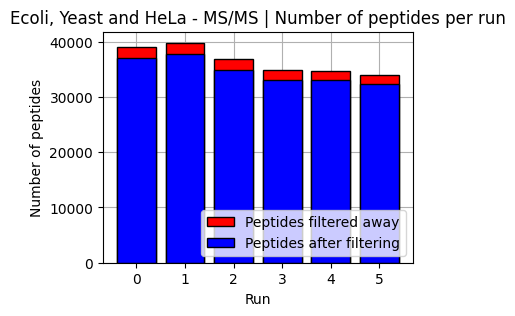

In [23]:
fig, ax = plt.subplots(figsize=(4, 3))

ax.bar(
    range(len(msms_species_raw_peptides_per_run)),
    msms_species_raw_peptides_per_run,
    color="red",
    edgecolor="black",
)
ax.bar(
    range(len(msms_species_peptides_per_run)),
    msms_species_peptides_per_run,
    color="blue",
    edgecolor="black",
)
ax.legend(["Peptides filtered away", "Peptides after filtering"], loc="lower right")

ax.grid(True)
ax.set_axisbelow(True)
ax.set_title("Ecoli, Yeast and HeLa - MS/MS | Number of peptides per run")
ax.set_xlabel("Run")
ax.set_ylabel("Number of peptides")

In [24]:
f"After filtering | MS/MS data points: {df_msms_species.shape[0]} ({df_msms_species.shape[0] / df_msms_species_raw.shape[0] * 100:.2f}%)"

'After filtering | MS/MS data points: 208091 (94.86%)'

Let's add a column with species.

In [25]:
yeast_filter = df_msms_species['Leading razor protein'].str.contains('YEAST')
ecoli_filter = df_msms_species['Leading razor protein'].str.contains('ECOLI')
hela_filter = ~(yeast_filter | ecoli_filter)

df_msms_species['Species'] = 'Unknown'
df_msms_species.loc[yeast_filter, 'Species'] = 'Yeast'
df_msms_species.loc[ecoli_filter, 'Species'] = 'Ecoli'
df_msms_species.loc[hela_filter, 'Species'] = 'HeLa'

Let's look at the proportion of peptides in each species for the MS2 dataset with multiple species.

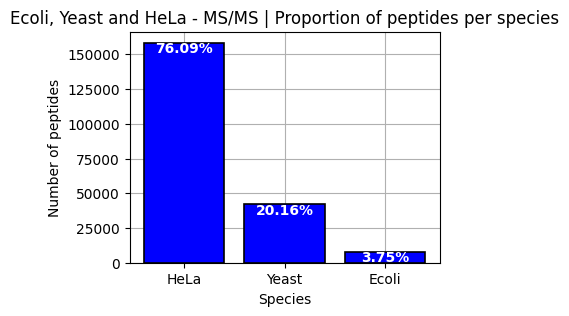

In [26]:
species = df_msms_species['Species']

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(species.value_counts().index, species.value_counts(), color='blue', edgecolor='black', linewidth=1.2)
ax.set_title('Ecoli, Yeast and HeLa - MS/MS | Proportion of peptides per species')
ax.set_xlabel('Species')
ax.set_ylabel('Number of peptides')
ax.grid(True)
ax.set_axisbelow(True)

for i, v in enumerate(species.value_counts()):
    y = v - 4000
    text = f"{v / df_msms_species.shape[0] * 100:.2f}%"
    ax.text(i, y, text, ha='center', va='center', fontweight='bold', color='white')

Save processed data.

In [27]:
df_ms_hela.to_csv(HELA_MS_OUT_PATH, index=False)
df_msms_hela.to_csv(HELA_MSMS_OUT_PATH, index=False)
df_msms_species.to_csv(SPECIES_MSMS_OUT_PATH, index=False)

In [28]:
df_ms_hela

,Raw file,Charge,m/z,Mass,Resolution,Number of data points,Number of frames,Number of isotopic peaks,Isotope correlation,Mass fractional part,...,Ion mobility index,Ion mobility length,Ion mobility index length (FWHM),Intensity,Intensities,Number of pasef MS/MS,Pasef MS/MS IDs,MS/MS scan number,dataset,id
18,20190122_HeLa_QC_Slot1-47_1_3219,3,338.52001,1012.5382,20884.156611,16778,45,2,0.986931,0.538192,...,633,54,27,47222.0,NaN,0,NaN,NaN,HeLa,18
44,20190122_HeLa_QC_Slot1-47_1_3219,3,376.48995,1126.4480,22896.168980,1113,7,2,0.654756,0.448008,...,615,102,54,50436.0,NaN,0,NaN,NaN,HeLa,44
291,20190122_HeLa_QC_Slot1-47_1_3219,3,373.48579,1117.4356,19579.931100,303,7,2,0.674029,0.435551,...,693,15,15,4560.5,NaN,0,NaN,NaN,HeLa,291
421,20190122_HeLa_QC_Slot1-47_1_3219,4,375.26205,1497.0191,10871.346645,111,5,2,0.885342,0.019077,...,708,9,9,3441.5,NaN,0,NaN,NaN,HeLa,421
460,20190122_HeLa_QC_Slot1-47_1_3219,3,375.46615,1123.3766,18534.680312,380,9,2,0.654371,0.376608,...,711,18,15,5453.3,NaN,0,NaN,NaN,HeLa,460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4101550,20190122_HeLa_QC_Slot1-47_1_3228,3,401.51001,1201.5082,25262.295341,93,4,2,0.979264,0.508215,...,957,9,9,3099.1,NaN,0,NaN,NaN,HeLa,4101550
4101551,20190122_HeLa_QC_Slot1-47_1_3228,3,363.15319,1086.4377,25378.536155,476,7,2,0.982066,0.437736,...,954,27,15,12634.0,NaN,6,41008;41018;41029;41040;41052;41062,15369.0,HeLa,4101551
4101552,20190122_HeLa_QC_Slot1-47_1_3228,3,348.16600,1041.4762,24875.051340,486,9,2,0.964573,0.476174,...,960,18,12,8744.4,NaN,9,35325;35333;35340;35348;35356;35366;35376;3538...,12463.0,HeLa,4101552
4101553,20190122_HeLa_QC_Slot1-47_1_3228,3,338.17870,1011.5143,25441.194149,542,9,2,0.950810,0.514278,...,960,21,15,9544.3,NaN,5,35407;35417;35426;35434;35442,10767.0,HeLa,4101553


In [29]:
df_ms_hela.columns

Index(['Raw file', 'Charge', 'm/z', 'Mass', 'Resolution',
       'Number of data points', 'Number of frames', 'Number of isotopic peaks',
       'Isotope correlation', 'Mass fractional part', 'Mass deficit',
       'Retention time', 'Retention length', 'Retention length (FWHM)',
       'Min frame index', 'Max frame index', 'Ion mobility index',
       'Ion mobility length', 'Ion mobility index length (FWHM)', 'Intensity',
       'Intensities', 'Number of pasef MS/MS', 'Pasef MS/MS IDs',
       'MS/MS scan number', 'dataset', 'id'],
      dtype='object')

In [30]:
df_msms_hela.head()

,Sequence,Length,Modifications,Modified sequence,Oxidation (M) Probabilities,Oxidation (M) Score Diffs,Acetyl (Protein N-term),Oxidation (M),Missed cleavages,Proteins,...,Protein group IDs,Peptide ID,Mod. peptide ID,MS/MS IDs,Best MS/MS,AIF MS/MS IDs,Oxidation (M) site IDs,dataset,PrecursorID,Species
2,AAAAAAAAAAGAAGGR,16,Acetyl (Protein N-term),_(ac)AAAAAAAAAAGAAGGR_,NaN,NaN,1,0,0,Q86U42,...,3443,2,2,20.0,20.0,NaN,NaN,HeLa,_(ac)AAAAAAAAAAGAAGGR_2,HeLa
63352,AAAAAAAAAAGAAGGR,16,Acetyl (Protein N-term),_(ac)AAAAAAAAAAGAAGGR_,NaN,NaN,1,0,0,Q86U42,...,3443,2,2,21.0,21.0,NaN,NaN,HeLa,_(ac)AAAAAAAAAAGAAGGR_2,HeLa
127924,AAAAAAAAAAGAAGGR,16,Acetyl (Protein N-term),_(ac)AAAAAAAAAAGAAGGR_,NaN,NaN,1,0,0,Q86U42,...,3443,2,2,22.0,22.0,NaN,NaN,HeLa,_(ac)AAAAAAAAAAGAAGGR_2,HeLa
192311,AAAAAAAAAAGAAGGR,16,Acetyl (Protein N-term),_(ac)AAAAAAAAAAGAAGGR_,NaN,NaN,1,0,0,Q86U42,...,3443,2,2,23.0,23.0,NaN,NaN,HeLa,_(ac)AAAAAAAAAAGAAGGR_2,HeLa
256739,AAAAAAAAAAGAAGGR,16,Acetyl (Protein N-term),_(ac)AAAAAAAAAAGAAGGR_,NaN,NaN,1,0,0,Q86U42,...,3443,2,2,24.0,24.0,NaN,NaN,HeLa,_(ac)AAAAAAAAAAGAAGGR_2,HeLa


In [31]:
df_msms_hela.columns

Index(['Sequence', 'Length', 'Modifications', 'Modified sequence',
       'Oxidation (M) Probabilities', 'Oxidation (M) Score Diffs',
       'Acetyl (Protein N-term)', 'Oxidation (M)', 'Missed cleavages',
       'Proteins', 'Leading proteins', 'Leading razor protein', 'Gene names',
       'Protein names', 'Type', 'Raw file', 'Experiment', 'MS/MS m/z',
       'Charge', 'm/z', 'Mass', 'Resolution',
       'Uncalibrated - Calibrated m/z [ppm]',
       'Uncalibrated - Calibrated m/z [Da]', 'Mass error [ppm]',
       'Mass error [Da]', 'Uncalibrated mass error [ppm]',
       'Uncalibrated mass error [Da]', 'Max intensity m/z 0', 'Retention time',
       'Retention length', 'Calibrated retention time',
       'Calibrated retention time start', 'Calibrated retention time finish',
       'Retention time calibration', 'Ion mobility index',
       'Ion mobility length', '1/K0', '1/K0 length', 'Calibrated 1/K0', 'CCS',
       'CCS length', 'Match time difference', 'Match m/z difference',
       '

In [32]:
df_msms_species.head()

,Sequence,Length,Modifications,Modified sequence,Oxidation (M) Probabilities,Oxidation (M) Score Diffs,Acetyl (Protein N-term),Oxidation (M),Missed cleavages,Proteins,...,Protein group IDs,Peptide ID,Mod. peptide ID,MS/MS IDs,Best MS/MS,AIF MS/MS IDs,Oxidation (M) site IDs,dataset,PrecursorID,Species
1,AAAAAAAAAAGAAGGR,16,Acetyl (Protein N-term),_(ac)AAAAAAAAAAGAAGGR_,NaN,NaN,1,0,0,Q86U42,...,3188,1,1,1,1,NaN,NaN,multi-species,_(ac)AAAAAAAAAAGAAGGR_2,HeLa
2,AAAAAAAAAAGAAGGR,16,Acetyl (Protein N-term),_(ac)AAAAAAAAAAGAAGGR_,NaN,NaN,1,0,0,Q86U42,...,3188,1,1,2,2,NaN,NaN,multi-species,_(ac)AAAAAAAAAAGAAGGR_2,HeLa
3,AAAAAAAAAAGAAGGR,16,Acetyl (Protein N-term),_(ac)AAAAAAAAAAGAAGGR_,NaN,NaN,1,0,0,Q86U42,...,3188,1,1,3,3,NaN,NaN,multi-species,_(ac)AAAAAAAAAAGAAGGR_2,HeLa
4,AAAAAAAAAAGAAGGR,16,Acetyl (Protein N-term),_(ac)AAAAAAAAAAGAAGGR_,NaN,NaN,1,0,0,Q86U42,...,3188,1,1,4,4,NaN,NaN,multi-species,_(ac)AAAAAAAAAAGAAGGR_2,HeLa
5,AAAAAAAAAAGAAGGR,16,Acetyl (Protein N-term),_(ac)AAAAAAAAAAGAAGGR_,NaN,NaN,1,0,0,Q86U42,...,3188,1,1,5,5,NaN,NaN,multi-species,_(ac)AAAAAAAAAAGAAGGR_2,HeLa
